In [3]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt

In [4]:
def M_Jac_iter(V,V0=1.0):
    Nx , Ny = V.shape
    for i in range(1,Nx-1):
        for j in range(1,Ny-1):
            if V[i,j] != 1:
                V[i,j] = 0.25*(V[i+1,j] + V[i-1,j] + V[i,j+1] + V[i,j-1])
    return V

def Met_Jac(V,V0=1,err=1e-3,step=20):
    diferencia = 1
    while diferencia > err:
        for i in range(step):
            V = M_Jac_iter(V,V0=V0)
        V_ref = M_Jac_iter(np.copy(V))
        diferencia = np.max(abs(V_ref-V))
    return V

def V_front_cuad(x,y,electrodo,V0=1):
    Nx , Ny = len(x) , len(y)
    malla = np.zeros((Nx,Ny))
    for i in range(1,Nx-1):
        for j in range(1,Ny-1):  #Este ciclo verifica si mu punto està dentro o fuera de mi figurita
            if  electrodo(x[i],y[j]) == True: #Caso donde està dentro
                malla[i,j] = 1 
            else:
                malla[i,j] = rd.random()  #Si està fuera le coloco un color aleatorio  
    return V0*malla

def M_mouse(x,y):
    respuesta = False
    c1 = x**2 + y**2
    c2 , c3 = (x-0.9)**2 + (y-0.9)**2 , (x+0.9)**2 + (y-0.9)**2
    if c1 <= 1 or c2 <= 0.35 or c3 <= 0.35:
        respuesta = True
    return respuesta


In [1]:
#Lleguè cuando empezò a aplicar la funciòn mouse

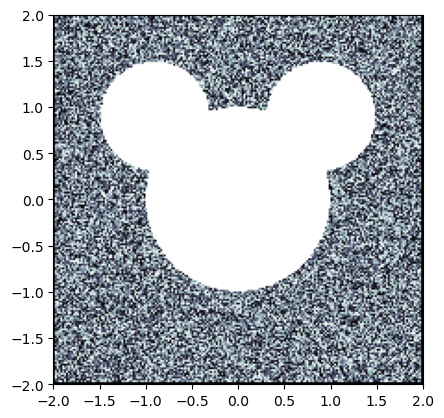

In [5]:
x , y = np.linspace(-2,2,200) , np.linspace(-2,2,200)
V = V_front_cuad(x,y,M_mouse)
plt.imshow( V.transpose(),
           extent=(x[0],x[-1],y[0],y[-1]),
           origin='lower',
           cmap='bone' )
plt.show()

In [6]:
#Agregamos el campo elèctrico tambien, en general podemos calcular lo de la clase pasada
V = Met_Jac(V)
Ex, Ey = np.gradient(-V.transpose())

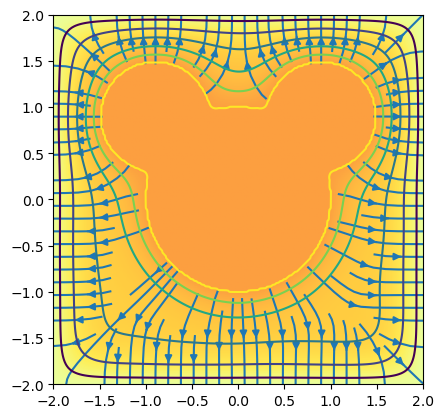

In [8]:
plt.imshow(V.transpose(),
           extent=(x[0],x[-1],y[0],y[-1]),
           origin='lower',
           cmap='Wistia',alpha=0.75)  #alpha es la transparencia de las lineas
niveles = np.linspace(0.1,0.99,6)
plt.streamplot(x,y,Ey,Ex)
plt.contour(x,y,V.transpose(),levels=niveles)
plt.gca().set_aspect('equal')
plt.show()

In [ ]:
#Si no quiero el mivkie mouse puedo definir otra funciòn con otra forma; copio y pego jj
def Mastercard(x,y):
    respuesta = False
    ci,c2 = 

In [ ]:
plt.imshow(V.transpose(),
           extent=(x[0],x[-1],y[0],y[-1]),
           origin='lower',
           cmap='Wistia',alpha=0.75)  #alpha es la transparencia de las lineas
niveles = np.linspace(0.1,0.99,6)
plt.streamplot(x,y,Ey,Ex)
plt.contour(x,y,V.transpose(),levels=niveles)
plt.gca().set_aspect('equal')
plt.show()

In [ ]:
#Abrimos un notebook nuevo